# Setup

#### Install required ROS2 packages

**1.:** Clone these repositories into the `src` folder of your ROS2 workspace:
- https://github.com/AIS-Bonn/nimbro_utils
- https://github.com/AIS-Bonn/nimbro_api
- https://github.com/AIS-Bonn/nimbro_api_interfaces

**2.:** Built all three packages:
```bash
colcon build --packages-select nimbro_utils nimbro_api nimbro_api_interfaces --symlink-install
```

**3.:** Source your workspace:
```bash
source install/local_setup.bash
```

#### Install Python dependencies

The only hard requirement of this package is the `requests` package:
```bash
pip install requests
```

To install all dependencies:
```bash
pip install -r requirements.txt
```

#### Install API keys

Save the API keys you plan on using to the corresponding environment variables.

OpenAI: 
```bash
echo "export OPENAI_API_KEY='yourkey'" >> ~/.bashrc`
```
Mistral:
```bash
echo "export MISTRAL_API_KEY='yourkey'" >> ~/.bashrc
```
OpenRouter:
```bash
echo "export OPENROUTER_API_KEY='yourkey'" >> ~/.bashrc
```
vLLM:
```bash
echo "export VLLM_API_KEY='yourkey'" >> ~/.bashrc
```
AIS:
```bash
echo "export AIS_API_KEY='yourkey'" >> ~/.bashrc
```
NimbRoVision:
```bash
echo "export NIMBRO_VISION_API_KEY='yourkey'" >> ~/.bashrc
```

#### Launch desired nodes

Dedicated launch files for all supported API types are provided.<br>
To conveniently launch them all at once:
```bash
ros2 launch nimbro_api launch.py
```
All provided launch files declare launch arguments that allow node parameters to be configured from the command line or from custom launch files.
```bash
ros2 launch nimbro_api launch.py -s
```

# Start Tutorial Node

#### Import

In [1]:
import os
import json
import time

import rclpy
from rclpy.node import Node

from nimbro_api import ApiDirector
from nimbro_utils.lazy import start_and_spin_node, stop_node

#### Define

In [2]:
class TutorialNode(Node):
    def __init__(self, context=None):
        super().__init__("nimbro_api_tutorial", context=context)
        self.api_director = ApiDirector(self)

#### Start and spin

In [3]:
node, executor, node_context, thread = start_and_spin_node(TutorialNode, blocking=False)

> Starting node 'TutorialNode'


The ApiDirector `node.api_director` can now be used to access all of this package's features.<br>
Note that most of the functions it provides return tuples in the form of (success, message, result_1, ...) for easy monitoring and validation of success.<br>
Additionally, most functions support the argument `retry[bool|int]`, which allows for retrying failed attempts either indefinitely or a specific number of times.

# API Examples

## Chat Completions API

### Manage completions nodes

Each completions node has a unique ID that is used for addressing during each interaction.<br>
This allows multiple completions nodes to be used and shared from anywhere in the ROS2 environment without interference.<br>
Similar to a semaphore, they must be acquired before use and released afterward.

#### Acquire

When acquiring a completions node, its model parameters and context can be conveniently reset.

In [4]:
success, message, completions_id = node.api_director.acquire(
    reset_parameters=True,
    reset_context=True
)

2025-09-22 20:15:03.127 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.acquire] Acquired completions node '/nimbro_api/completions_1'.
2025-09-22 20:15:03.139 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Reset parameters of completions node '/nimbro_api/completions_1' to default values.
2025-09-22 20:15:03.148 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_context] Kept empty context.


#### Release

In [5]:
success, message = node.api_director.release(completions_id=completions_id)

2025-09-22 20:15:03.161 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.release] Released completions node '/nimbro_api/completions_1'.


#### Duplicate

A new completions node can be acquired by duplicating the entire state of another completions node, including its context, model parameters, and tool definitions.

In [6]:
success, message, completions_id = node.api_director.duplicate(completions_id=completions_id)

2025-09-22 20:15:03.178 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.acquire] Acquired completions node '/nimbro_api/completions_1'.
2025-09-22 20:15:03.192 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Reset parameters of completions node '/nimbro_api/completions_1' to default values.
2025-09-22 20:15:03.205 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_context] Kept empty context.
2025-09-22 20:15:03.217 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.get_parameters] Retrieved parameters of completions node '/nimbro_api/completions_1'.
2025-09-22 20:15:03.239 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Set parameters of completions node '/nimbro_api/completions_1'.
2025-09-22 20:15:03.249 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.get_tools] There are no tools defined.
2025-09-22 20:15:03.258 [INFO] [ni

#### Status

The number of available completions nodes and their status can be obtained easily.

In [7]:
success, message, completions_ids, completions_acquired = node.api_director.get_status()
if success:
    time.sleep(0.1)
    print("\nNumber of completions nodes:", len(completions_ids))
    print("Completions acquired:", completions_acquired)
    print("Completions IDs:", completions_ids)

2025-09-22 20:15:03.294 [INFO] [nimbro_api_tutorial.api_director]: [completions.get_status] '1' of '7' completions nodes is currently acquired.

Number of completions nodes: 7
Completions acquired: [True, False, False, False, False, False, False]
Completions IDs: ['/nimbro_api/completions_1', '/nimbro_api/completions_2', '/nimbro_api/completions_3', '/nimbro_api/completions_4', '/nimbro_api/completions_5', '/nimbro_api/completions_6', '/nimbro_api/completions_7']


#### Parameters

The parameters of a completions node can be obtained, set, and reset.

In [8]:
success, message, parameters = node.api_director.get_parameters(completions_id=completions_id)
if success:
    time.sleep(0.1)
    print("\nParameters:")
    print(json.dumps(parameters, indent=4))

2025-09-22 20:15:03.411 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.get_parameters] Retrieved parameters of completions node '/nimbro_api/completions_1'.

Parameters:
{
    "probe_api_connection": "True",
    "api_endpoint": "OpenRouter",
    "model_name": "google/gemini-2.5-flash",
    "model_temperature": "1.0",
    "model_top_p": "1.0",
    "model_max_tokens": "5000",
    "model_presence_penalty": "0.0",
    "model_frequency_penalty": "0.0",
    "model_reasoning_effort": "none",
    "completion_parsers": "[\"\"]",
    "completion_parsers_timeout": "5.0",
    "completion_parsers_folder": "/home/paetzoldb0/ws/jazzy/main/src/nimbro_api/nimbro_api/misc/parsers/completion",
    "stream_completion": "True",
    "normalize_text_completion": "False",
    "max_tool_calls_per_completion": "1",
    "correction_attempts": "0",
    "timeout_chunk_first": "10.0",
    "timeout_chunk_next": "5.0",
    "timeout_completion": "20.0"
}


In [9]:
parameters = {
    # logging related parameters not returned by `get_parameters` and ignored by `reset`
    # 'severity': "10",
    # 'log_line_length': "150",
    # 'log_last_messages': "0",
    # 'log_chunks': "False",

    # instead of setting a known API endpoint by its name, a new API endpoint can be defined
    # 'api_endpoint': json.dumps({
    #     'name': "local",
    #             'api_flavor': "vllm",
    #             'models_url': "http://my_server:8000/v1/models",
    #             'completions_url': "http://my_server:8000/v1/chat/completions",
    #             # 'key_type': "environment",
    #             # 'key_value': "MY_API_KEY"
    #             'key_type': "plain",
    #             'key_value': "MyKey123"
    # }),

    # 'api_endpoint': "OpenRouter",
    # 'model_name': "google/gemini-2.5-flash",
    # 'model_name': "openai/gpt-5-mini",
    # 'model_name': "anthropic/claude-sonnet-4",
    # 'model_name': "deepseek/deepseek-chat-v3-0324",
    # 'model_name': "x-ai/grok-code-fast-1",
    # 'model_name': "qwen/qwen3-30b-a3b",

    # 'api_endpoint': "OpenAI",
    # 'model_name': "gpt-5-mini",
    # 'model_name': "gpt-4o-mini",
    # 'model_name': "o3-mini",

    # 'api_endpoint': "Mistral AI",
    # 'model_name': "voxtral-small-latest",
    # 'model_name': "mistral-large-latest",

    # 'model_temperature': "0.7",
    # 'model_max_tokens': "5000",
    'model_reasoning_effort': "high",
    # 'stream_completion': "False",
    # 'completion_parsers': '["reasoning_extractor.py", "json_decoder.py"]',
    # 'normalize_text_response': "False",
    # 'correction_attempts': "0",
    # 'timeout_chunk_first': "5.0",
    # 'timeout_chunk_next': "2.0",
    # 'timeout_completion': "20.0"
}
success, message = node.api_director.set_parameters(
    completions_id=completions_id,
    parameter_names=list(parameters.keys()),
    parameter_values=list(parameters.values())
)

2025-09-22 20:15:03.534 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Set parameters of completions node '/nimbro_api/completions_1'.


In [10]:
success, message = node.api_director.reset_parameters(completions_id=completions_id)

2025-09-22 20:15:03.560 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Reset parameters of completions node '/nimbro_api/completions_1' to default values.


Model parameters are reset to their launch time state.

### Prompt

The `prompt` function is the central mechanism for triggering a chat completion, but it can also be used to reset and add messages to the the context without triggering a completion.

#### System prompt & text completion

In [11]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text='You are a helpful assistant.',
    role="system",
    reset_context=True,
    response_type="none"
)

2025-09-22 20:15:03.583 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Added request to context without generating a completion.


In [12]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text='Tell me a joke about robots.',
    response_type='text'
)
if success:
    time.sleep(0.1)
    print("\nCompletion:")
    print(json.dumps(completion, indent=4))

2025-09-22 20:15:04.849 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '18' tokens in '0.9s'.

Completion:
{
    "usage": {
        "api_type": "completions",
        "api_endpoint": "OpenRouter",
        "model_name": "google/gemini-2.5-flash",
        "stamp_start": "2025-09-22T20:15:03.917416",
        "stamp_stop": "2025-09-22T20:15:04.826591",
        "duration": 0.909175,
        "tokens_input_uncached": 13,
        "tokens_output": 18
    },
    "text": "Why did the robot break up with the internet?\n\nBecause they kept having bandwidth issues!",
    "logs": [
        "Generated completion with '18' tokens in '0.9s'."
    ]
}


#### JSON mode

Set the response type `response_type='json'` to activate JSON-mode.<br>
Make sure to also instruct the model to respond with JSON in the `text` argument.

In [13]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text='Tell me a joke about robots in json format.',
    response_type='json',
    reset_context=True
)
if success:
    time.sleep(0.1)
    print(f"\nText completion: (type '{type(completion['text']).__name__}')")
    print(json.dumps(completion['text'], indent=4))

2025-09-22 20:15:06.890 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '34' tokens in '1.0s'.

Text completion: (type 'dict')
{
    "setup": "Why did the robot go to the convenience store?",
    "punchline": "Because he needed some 'bytes'!"
}


#### Web search

Currently, web search is only supported with OpenRouter by appending ":online" to the model name.

In [14]:
parameters = {
    'api_endpoint': "OpenRouter",
    'model_name': "google/gemini-2.5-flash:online",
}
success, message = node.api_director.set_parameters(
    completions_id=completions_id,
    parameter_names=list(parameters.keys()),
    parameter_values=list(parameters.values())
)

2025-09-22 20:15:06.135 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Set parameters of completions node '/nimbro_api/completions_1'.


In [15]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text='Summarize the most important news story of the week in one sentence.',
    reset_context=True
)
if success:
    time.sleep(0.1)
    print(f"\nText completion: '{completion['text']}'")

2025-09-22 20:15:10.199 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '177' tokens in '4.0s'.

Text completion: 'Nvidia plans to invest up to $100 billion in OpenAI as part of a strategic partnership to deploy at least 10 gigawatts of Nvidia’s AI systems for OpenAI's infrastructure, aiming to accelerate AI growth and address the increasing demand for energy and chips in the sector [ft.com](https://www.ft.com/content/d3caeac1-def8-45ae-b56b-e34c7c435ccc), [biztoc.com](https://biztoc.com/x/956917ac11c52198?ref=rss), [techmeme.com](https://www.techmeme.com/250922/p17#a250922p17).'


In [16]:
node.api_director.reset_parameters(completions_id=completions_id)

2025-09-22 20:15:10.328 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_parameters] Reset parameters of completions node '/nimbro_api/completions_1' to default values.


(True,
 "Reset parameters of completions node '/nimbro_api/completions_1' to default values.")

#### Image inputs

Images can be passed to the `prompt` function using `role='json'` and passing a valid dictionary.<br>
The given URL can be a web address, a path in the local file system, or a base64 encoded image.<br>
Please note that not all models support this feature.

In [17]:
image_url = "https://www.nimbro.net/AVATAR/images/NimbRo_Avatar_2022_11_01_Team.jpg"

prompt_dict = {"role": "user", "content": [
    {'type': "text", 'text': "Please describe this image in one sentence."},
    {'type': "image_url", 'image_url': {'url': image_url, 'detail': "high"}}
]}

success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text=prompt_dict,
    role="json",
    reset_context=True
)

if success:
    time.sleep(0.1)
    print(f"\nText completion: '{completion['text']}'")

2025-09-22 20:15:13.789 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '56' tokens in '3.4s'.

Text completion: 'A group of seven men wearing casual clothing, most of whom are sporting hooded sweatshirts with the "NimbRo" logo, are gathered in front of a large black sign detailing "NIMBRO BONN, GERMANY" and "ABOUT THE TEAM" at the X Prize Avatar event.'


#### File inputs

`.pdf` files can be passed to the `prompt` function using `role='json'` and passing a valid dictionary.<br>
The provided data can be a web address, a path in the local file system, or a base64 encoded file.<br>
Please note that not all models support this feature.

In [18]:
file = "https://bitcoin.org/bitcoin.pdf"

prompt_dict = {"role": "user", "content": [
    {'type': "text", 'text': "Please describe this file in one sentence."},
    {'type': "file", 'file': {'filename': "paper.pdf", 'file_data': file}}
]}

success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text=prompt_dict,
    role="json",
    reset_context=True
)

if success:
    time.sleep(0.1)
    print(f"\nText completion: '{completion['text']}'")

2025-09-22 20:15:19.250 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '47' tokens in '5.3s'.

Text completion: 'This white paper introduces a peer-to-peer electronic cash system called Bitcoin, which addresses the double-spending problem without relying on a financial institution, by using a distributed timestamp server to generate computational proof of the chronological order of transactions.'


#### Audio inputs

Audio files can be passed to the `prompt` function using `role='json'` and passing a valid dictionary.<br>
The provided data can be a web address (not supported by most providers), a path in the local file system, or a base64 encoded audio file.<br>
Please note that not all models support this feature.

In [19]:
# Set a valid file. Otherwise, the string will be interpreted as Base64, resulting in a server error.
input_audio = os.path.abspath("./../cache/speech/2025_08_23_22_03_59.wav")
if not os.path.isfile(input_audio):
    input_audio = None

# Currently, only Mistral AI supports passing web addresses.
# input_audio = "https://download.samplelib.com/mp3/sample-15s.mp3"

prompt_dict = {"role": "user", "content": [
    {'type': "text", 'text': "Please describe this audio file in one sentence."},
    {'type': "input_audio", 'input_audio': {'data': input_audio, 'format': "wav"}}
]}

success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text=prompt_dict,
    role="json",
    reset_context=True
)

if success:
    time.sleep(0.1)
    print(f"\nText completion: '{completion['text']}'")

2025-09-22 20:15:21.164 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '37' tokens in '1.6s'.

Text completion: 'A robotic voice introduces itself as Tiago, a domestic service robot from the Autonomous Intelligent Systems Group at the University of Bonn, followed by a brief, high-pitched ringing sound.'


In [20]:
from nimbro_utils.lazy import read_as_b64

success, message, b = read_as_b64(input_audio)

#### Asynchronous prompting

Since `prompt` is blocking, there is an asynchronous version of it that allows multiple prompts to be queued without blocking.<br>
It returns an ID that can be used to query the result, and allows for specifying an execution order via the `succeed_async_id` argument.

In [21]:
success, message, async_id_one = node.api_director.async_prompt(
    completions_id=completions_id,
    text='Tell me a joke about robots.',
    reset_context=True
)
success, message, async_id_two = node.api_director.async_prompt(
    completions_id=completions_id,
    text='Exlpain whats funny about it.',
    succeed_async_id=async_id_one
)

2025-09-22 20:15:21.152 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Registered asynchronous thread '1758564921_147618305_tZIpuQFh'.
2025-09-22 20:15:21.155 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Registered asynchronous thread '1758564921_152587429_O1fD7y65'.


The progress of all asynchronous events can be monitored.

Results can be obtained via the appropriate ID.<br>
Specifying a timeout allows for waiting on the results.

In [22]:
success, message, result = node.api_director.async_get(async_id_one, timeout=None)
if success:
    time.sleep(0.1)
    success, message, completion = result
    if success:
        print(f"\nText completion: '{completion['text']}'")

2025-09-22 20:15:22.165 [INFO] [nimbro_api_tutorial.api_director]: [completions.async_get.1758564921_147618305_tZIpuQFh] Waiting for response from asynchronous thread since '1.000s'.
2025-09-22 20:15:22.684 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '32' tokens in '1.5s'.
2025-09-22 20:15:22.686 [INFO] [nimbro_api_tutorial.api_director]: [completions.async_get.1758564921_147618305_tZIpuQFh] Retrieved response from asynchronous thread after waiting '1.521s'.

Text completion: 'Why did the robot break up with the calculator?

He felt like she was just adding to his problems, and he needed some space to process his feelings.'


The ApiDirector provides functions in the same style for setting parameters and defining tools asynchronously.

### Context

The context can be inspected.

In [23]:
success, message, context = node.api_director.get_context(completions_id=completions_id)

if success:
    time.sleep(0.1)
    for i, m in enumerate(context):
        if i == 0:
            print("\nContext:")
        elif i < len(context):
            print("    ---")
        if len(str(m)) > 200:
            print(f"    {i}: {m[:200]}...")
        else:
            print(f"    {i}: {m}")

2025-09-22 20:15:22.810 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.get_context] Retrieved context.

Context:
    0: {'role': 'user', 'content': [{'type': 'text', 'text': 'Tell me a joke about robots.'}]}
    ---
    1: {'role': 'assistant', 'content': 'Why did the robot break up with the calculator?\n\nHe felt like she was just adding to his problems, and he needed some space to process his feelings.'}
    ---
    2: {'role': 'user', 'content': [{'type': 'text', 'text': 'Exlpain whats funny about it.'}]}


The context can be edited.

In [24]:
success, message = node.api_director.set_context(
    completions_id=completions_id,
    mode="remove", # Modes: reset, insert, remove, replace
    new_messages=None,
    index=0,
    indexing_last_to_first=True
)

2025-09-22 20:15:25.760 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '398' tokens in '3.0s'.
2025-09-22 20:15:25.762 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_context] Removed message '3' from context.


### Tools

Define some tools.

In [25]:
tools = [
    {
        "name": "get_current_weather",
        "description": "Get the current weather at the current location",
        "parameters": {
            "type": "object",
            "properties": {}
        }

    },
    {
        "name": "get_current_time",
        "description": "Get the current time at the current location",
        "parameters": {
            "type": "object",
            "properties": {}
        }
    },
    {
        'name': "speak",
        'description': "Speak to a person, e.g. the user. Never use plain text repsonses to address anyone.",
        'parameters': {
            'type': 'object',
            'properties': {
                'person': {
                    'type': "string",
                    'description': "Specifies the person to speak to. Pass 'everyone' to address everyone in the robot's vicinity, rather than a specific person"
                },
                "text": {
                    'type': "string",
                    'description': "Specifies the text to be said. Be friendly, concise, and helpful"
                },
                "requires_answer": {
                    'type': "boolean",
                    'description': "Signals that the spoken text requires an answer and makes the robot wait for it. The answer will then be returned with the response to this function call"
                }
            },
            'required': ['person', "text", "requires_answer"]
        }
    }
]

success, message = node.api_director.set_tools(
    completions_id=completions_id,
    tools=tools
)

2025-09-22 20:15:25.851 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_tools] Set tools.


Inspect all defined tools.

In [26]:
success, message, tools = node.api_director.get_tools(completions_id=completions_id)
if success:
    time.sleep(0.1)
    print(f"\nTool definitions:")
    for i, tool in enumerate(tools):
        print(f"\n{i}:\n{json.dumps(tool, indent=4)}")

2025-09-22 20:15:25.873 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.get_tools] Retrieved tools.

Tool definitions:

0:
{
    "name": "get_current_weather",
    "description": "Get the current weather at the current location",
    "parameters": {
        "type": "object",
        "properties": {}
    }
}

1:
{
    "name": "get_current_time",
    "description": "Get the current time at the current location",
    "parameters": {
        "type": "object",
        "properties": {}
    }
}

2:
{
    "name": "speak",
    "description": "Speak to a person, e.g. the user. Never use plain text repsonses to address anyone.",
    "parameters": {
        "type": "object",
        "properties": {
            "person": {
                "type": "string",
                "description": "Specifies the person to speak to. Pass 'everyone' to address everyone in the robot's vicinity, rather than a specific person"
            },
            "text": {
                "type": "stri

Tools are used via the response types `auto`, `always` and `<tool_name>`.<br>
A tool returns an ID that must be passed with the response to `tool_response_id` along with `role='tool'`.

In [27]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    text='You are a helpful tool assistant.',
    role='system',
    response_type='none',
    reset_context=True
)

if success:
    success, message, completion = node.api_director.prompt(
        completions_id=completions_id,
        text='Tell Michael how warm it is outside.',
        response_type='always'
    )
    if success:
        time.sleep(0.1)
        print("\nTool call:")
        print(json.dumps(completion['tools'][0], indent=4))

2025-09-22 20:15:25.996 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Added request to context without generating a completion.
2025-09-22 20:15:26.933 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '5' tokens in '0.9s'.

Tool call:
{
    "id": "tool_0_get_current_weather_oVaIsGewaioOPOWYWvFw",
    "name": "get_current_weather",
    "arguments": {}
}


In [28]:
assert 'tools' in completion
tool_calls = completion['tools']
assert isinstance(tool_calls, list)
assert len(tool_calls) == 1
assert isinstance(tool_calls[0], dict)
assert "id" in tool_calls[0] and "name" in tool_calls[0] and "arguments" in tool_calls[0]
assert tool_calls[0]["name"] == "get_current_weather"

In [29]:
success, message, completion = node.api_director.prompt(
    completions_id=completions_id,
    role="tool",
    text='The sun is shining and it is 42°C.',
    tool_response_id=tool_calls[0]['id'],
    response_type='always'
)
if success:
    time.sleep(0.1)
    print("\nTool call:")
    print(json.dumps(completion['tools'][0], indent=4))

2025-09-22 20:15:27.900 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '22' tokens in '0.8s'.

Tool call:
{
    "id": "tool_0_speak_wEMJkLyeTyCZ4HRlCUhU",
    "name": "speak",
    "arguments": {
        "person": "Michael",
        "text": "The sun is shining and it is 42 degrees Celsius outside.",
        "requires_answer": false
    }
}


In [30]:
assert 'tools' in completion
tool_calls = completion['tools']
assert isinstance(tool_calls, list)
assert len(tool_calls) == 1
assert isinstance(tool_calls[0], dict)
assert "id" in tool_calls[0] and "name" in tool_calls[0] and "arguments" in tool_calls[0]
assert tool_calls[0]["name"] == "speak"
assert "person" in tool_calls[0]["arguments"] and "text" in tool_calls[0]["arguments"] and "requires_answer" in tool_calls[0]["arguments"]
assert tool_calls[0]["arguments"]["person"] == "Michael"

In [31]:
success, message, completion =  node.api_director.prompt(
    completions_id=completions_id,
    role="tool",
    text='Ok, thank you.',
    tool_response_id=tool_calls[0]['id'],
    response_type='always'
)
if success:
    time.sleep(0.1)
    print("\nTool call:")
    print(json.dumps(completion['tools'][0], indent=4))

2025-09-22 20:15:28.863 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.prompt] Generated completion with '13' tokens in '0.8s'.

Tool call:
{
    "id": "tool_0_speak_LeyxN27gbHVngVg8fXPd",
    "name": "speak",
    "arguments": {
        "text": "You are welcome Michael!",
        "person": "Michael",
        "requires_answer": false
    }
}


Tools can be reset by setting them to None or an empty list.

In [32]:
success, message = node.api_director.set_tools(
    completions_id=completions_id,
    tools=None
)

2025-09-22 20:15:28.984 [INFO] [nimbro_api_tutorial.api_director]: [/nimbro_api/completions_1.set_tools] Undefined all tools.


### Release all acquired completions nodes 

In [33]:
success, message = node.api_director.release(completions_id=None)

2025-09-22 20:15:29.268 [INFO] [nimbro_api_tutorial.api_director]: [completions.release] Released completions node '['/nimbro_api/completions_1']'.


## Embeddings API

Retrieve some text embeddings.<br>
All retrieved embeddings are cached by default.

In [34]:
success, message, embedding = node.api_director.get_embeddings(text="cat")

2025-09-22 20:15:29.420 [INFO] [nimbro_api_tutorial.api_director]: [embeddings] Retrieved '1' embedding.


In [35]:
success, message, embeddings = node.api_director.get_embeddings(text=["dog", "helicopter"])

2025-09-22 20:15:29.601 [INFO] [nimbro_api_tutorial.api_director]: [embeddings] Retrieved '2' embeddings.


Compute similarities between embedding vectors.

In [36]:
from nimbro_utils.lazy import cosine_similarity
print("cat", "dog       ", cosine_similarity(embedding, embeddings[0]))
print("cat", "helicopter", cosine_similarity(embedding, embeddings[1]))

cat dog        0.5907189574408478
cat helicopter 0.25320085154204997


## Images API

Generate an image.<br>
All retrieved images are cached by default.

In [37]:
success, message, image_path = node.api_director.get_images(
    prompt="An image of The Evil Power in Mirkwood.",
    model="dall-e-3",
    quality="standard",
    style="vivid",
    size="1792x1024"
)

2025-09-22 20:15:29.858 [INFO] [nimbro_api_tutorial.api_director]: [images] Retrieved image.


Image '/home/paetzoldb0/ws/jazzy/main/src/nimbro_api/cache/images/2025_08_23_21_19_41.png':


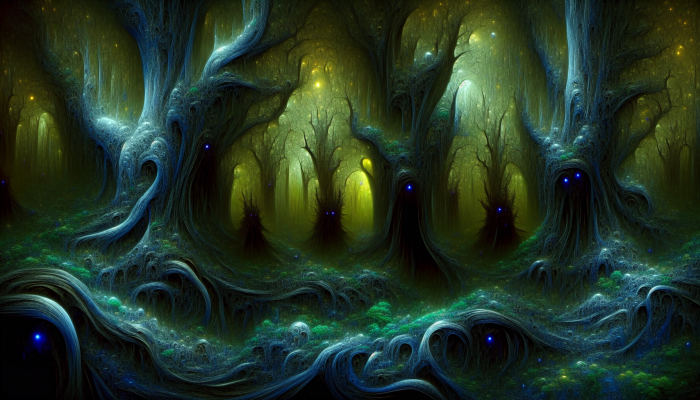

In [38]:
print(f"Image '{image_path}':")

from nimbro_utils.lazy import show_image
show_image(image_path, width=700)

# from IPython.display import Image, display
# Image(image_path)

## Speech API

Generate speech.<br>
All retrieved audio files are cached by default.

In [39]:
success, message, speech_path = node.api_director.get_speech(
    text="Hello, my name is Thiago. I am a domestic service robot of the Autonomous Intelligent Systems group at University of Bonn.",
    model="tts-1-hd",
    voice="alloy",
    speed=1.0
)

2025-09-22 20:15:30.530 [INFO] [nimbro_api_tutorial.api_director]: [speech] Retrieved speech.


In [40]:
print(f"Speech '{speech_path}':")
from IPython.display import Audio
Audio(filename=speech_path)

Speech '/home/paetzoldb0/ws/jazzy/main/src/nimbro_api/cache/speech/2025_08_23_22_07_20.wav':


Some models may support text instructions for the style and tone of the generated speech.<br>
See [here](./nimbro_api/misc/voice_presets.json) for voice presets recommended by OpenAI.

In [41]:
success, message, speech_path = node.api_director.get_speech(
    text="Hello, my name is Thiago. I am a domestic service robot of the Autonomous Intelligent Systems group at University of Bonn.",
    model="gpt-4o-mini-tts",
    voice="alloy",
    speed=1.0,
    instructions="Whisper the provided text very very extremely quitely."
)

2025-09-22 20:15:30.100 [INFO] [nimbro_api_tutorial.api_director]: [speech] Retrieved speech.


In [42]:
print(f"Speech '{speech_path}':")
from IPython.display import Audio
Audio(filename=speech_path)

Speech '/home/paetzoldb0/ws/jazzy/main/src/nimbro_api/cache/speech/2025_08_23_22_16_26.wav':


## NimbRo Vision API

In [43]:
import cv2
import numpy as np
from nimbro_utils.lazy import download_image, encode_b64, decode_mask, visualize_detections, convert_image, show_image

#### MM-GroundingDINO Detection

In [44]:
image_url = "https://www.ais.uni-bonn.de/nimbro/@Home/images/RC24/RoboCup_2024_NimbRo_Home_Final_4__07_21.jpg"

det_prompts = ["robot", "flower pot", "couch table"]

if not os.path.isfile(image_url):
    success, message, img_np = download_image(image_url, logger=node.get_logger())
else:
    img_np = convert_image(image_url, logger=node.get_logger())

if success:
    img_bytes = cv2.imencode('.jpg', img_np)[1].tobytes()
    success, message, img_b64 = encode_b64(img_bytes, logger=node.get_logger())
    if success:
        success, message, detections = node.api_director.mmgroundingdino(
            image=img_b64,
            model_id=0,
            model_flavor="large",
            prompts=det_prompts,
            min_confidence=0.0,
            nms_iou=0.6,
            overdetect_factor=1.0,
            retry=False
        )

2025-09-22 20:15:30.892 [INFO] [nimbro_api_tutorial.api_director]: [vision.mmgd] Retrieved inference response from model 'mmgroundingdino' with flavor 'large' after '0.411s'.


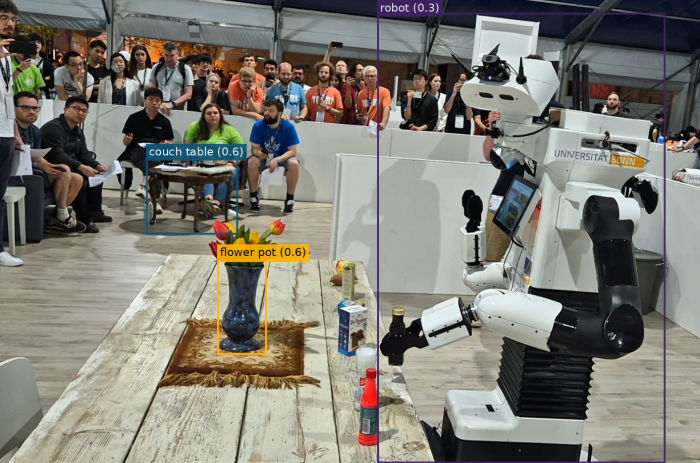

In [45]:
bboxes = [detection['box_xyxy'] for detection in detections]
confidences = [detection['confidence'] for detection in detections]
det_prompts = [detection['prompt'] for detection in detections]
labels = [f"{p} ({c:.1f})" for p, c in zip(det_prompts, confidences)]

visualization = visualize_detections(
    image=img_np,
    boxes=bboxes,
    labels=labels,
    box_format="xyxy_absolute"
)
show_image(visualization, width=700)

#### SAM2 Segmentation

In [46]:
box_prompts = [{'object_id': idx, 'bbox': det['box_xyxy']} for idx, det in enumerate(detections)]
points_prompts = [
    {'object_id': 41, 'points': [[80,415], [120,460]], 'labels': [1, 0]},
    {'object_id': 42, 'points': [[560,215], [580,270]], 'labels': [1, 0]}
]
sam_prompts = box_prompts# + points_prompts
print("Prompts:", sam_prompts, "\n")

success, message, segmentations = node.api_director.sam2_realtime_update(
    image=img_b64,
    prompts=sam_prompts,
    model_id=0,
    model_flavor="large"
)

if success:
    time.sleep(0.1)
    print("\nNumber of segmented detections:", len(segmentations))

Prompts: [{'object_id': 0, 'bbox': [293, 318, 467, 460]}, {'object_id': 1, 'bbox': [434, 519, 524, 698]}, {'object_id': 2, 'bbox': [751, 29, 1314, 913]}] 

2025-09-22 20:15:31.488 [INFO] [nimbro_api_tutorial.api_director]: [vision.sam2_update] Retrieved update response from model 'sam2_realtime' with flavor 'large' after '0.287s'.

Number of segmented detections: 3


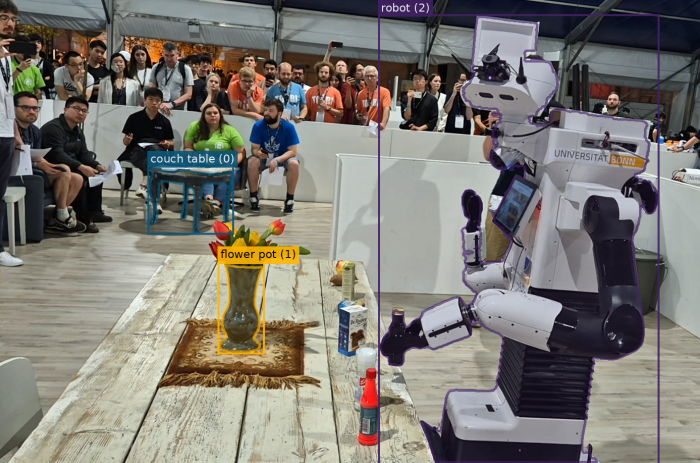

In [47]:
bboxes = [track['box_xyxy'] for track in segmentations]
masks = [decode_mask(track['mask']) for track in segmentations]

masks = []
for i, track in enumerate(segmentations):
    mask_decoded = np.full(img_np.shape[:2], fill_value=False)
    mask_decoded[bboxes[i][1]:bboxes[i][3], bboxes[i][0]:bboxes[i][2]] = decode_mask(track['mask'])
    masks.append(mask_decoded)

track_ids = [track['track_id'] for track in segmentations]
labels = [f"{p} ({i})" for p, i in zip(det_prompts, track_ids)]

visualization = visualize_detections(
    image=img_np,
    boxes=bboxes,
    masks=masks,
    labels=labels,
    box_format="xyxy_absolute"
)
show_image(visualization, width=700)

#### SAM2 Tracking

In [48]:
success, message, tracks = node.api_director.sam2_realtime_track(
    image=img_b64,
    model_id=0
)
if success:
    time.sleep(0.1)
    print("\nNumber of tracked segmentations:", len(tracks))

2025-09-22 20:15:32.339 [INFO] [nimbro_api_tutorial.api_director]: [vision.sam2_track] Retrieved tracking response from model 'sam2_realtime' after '0.144s'.

Number of tracked segmentations: 3


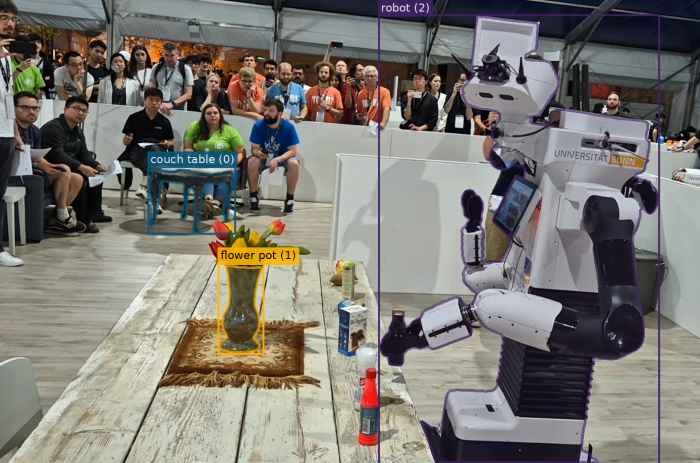

In [49]:
bboxes = [track['box_xyxy'] for track in tracks]
masks = [decode_mask(track['mask']) for track in tracks]

masks = []
for i, track in enumerate(tracks):
    mask_decoded = np.full(img_np.shape[:2], fill_value=False)
    mask_decoded[bboxes[i][1]:bboxes[i][3], bboxes[i][0]:bboxes[i][2]] = decode_mask(track['mask'])
    masks.append(mask_decoded)

track_ids = [track['track_id'] for track in tracks]
labels = [f"{p} ({i})" for p, i in zip(det_prompts, track_ids)]

visualization = visualize_detections(
    image=img_np,
    boxes=bboxes,
    masks=masks,
    labels=labels,
    box_format="xyxy_absolute"
)
show_image(visualization, width=700)

#### DAM Description

In [50]:
dam_prompts = [{'mask': track['mask'], 'bbox': track['box_xyxy']} for track in tracks]

success, message, descriptions = node.api_director.dam(
    image=img_b64,
    prompts=dam_prompts,
    query="Describe the masked region in detail.",
    model_flavor="3B",
    temperature=0.2,
    top_p=0.5,
    num_beams=1,
    max_new_tokens=512,
    max_batch_size=32
)

if success:
    time.sleep(0.1)
    print()
    for i, d in enumerate(descriptions):
        print(f"{i}:")
        print(f"- Detector prompt: '{det_prompts[i]}'")
        print(f"- DAM description: '{d}'")

2025-09-22 20:15:34.893 [INFO] [nimbro_api_tutorial.api_director]: [vision.dam] Retrieved inference response from model 'dam' with flavor '3B' after '1.872s'.

0:
- Detector prompt: 'couch table'
- DAM description: 'A dark wooden table with a rectangular top and four elegantly curved legs. The legs are connected by a lower horizontal support beam, creating a stable base. The table has a smooth, polished finish.'
1:
- Detector prompt: 'flower pot'
- DAM description: 'A tall, slender vase with a glossy, dark blue finish. The vase has a slightly flared rim and a bulbous base that tapers into a narrow neck. The surface features subtle, irregular patterns and a few reflective spots.'
2:
- Detector prompt: 'robot'
- DAM description: 'The robot is a white, articulated model with a humanoid shape, featuring a prominent head with a pair of black, circular eyes and a small, rectangular display screen. It has a black, cylindrical torso with a ribbed texture, and its arms are white with black join

## Usage Monitoring

Detailed usage information (cost, tokens, times, etc.) can retrieved for the Chat Completions and Embeddings APIs.

In [51]:
success, message, usage = node.api_director.get_usage()

2025-09-22 20:15:36.504 [INFO] [nimbro_api_tutorial.api_director]: [usage] Retrieved usage in '0.672s'.


By providing ISO timestamps, the retrieved usage can filtered.

In [52]:
import datetime
stamp_iso_start = (datetime.datetime.now() - datetime.timedelta(minutes=20)).isoformat()
stamp_iso_end = (datetime.datetime.now() - datetime.timedelta(seconds=0)).isoformat()

print("Start:", stamp_iso_start)
print("End:", stamp_iso_end, "\n")

success, message, usage = node.api_director.get_usage(stamp_start=stamp_iso_start, stamp_end=stamp_iso_end)

if success:
    time.sleep(0.1)
    print("\nCost:")
    print(f"  Chat Completions: {usage.get('completions', {}).get('dollars_total', 0):.5f}$")
    print(f"  Embeddings: {usage.get('embeddings', {}).get('dollars_input', 0):.5f}$")
    print(f"  Total: {usage.get('dollars_total', 0):.5f}$")

Start: 2025-09-22T19:55:36.515728
End: 2025-09-22T20:15:36.515834 

2025-09-22 20:15:36.597 [INFO] [nimbro_api_tutorial.api_director]: [usage] Retrieved usage in '0.076s'.

Cost:
  Chat Completions: 0.00363$
  Embeddings: 0.00000$
  Total: 0.00363$


# Stop Tutorial Node

In [53]:
stop_node(node, executor, node_context, thread)

> Stopped node 'TutorialNode'
